# 🩺 Prediksi Risiko Prediabetes Berdasarkan Faktor Gaya Hidup
## Menggunakan Model XGBoost
---
### 📋 Ringkasan Keputusan

| Item | Keputusan |
|---|---|
| **Target Label** | `Risk_Level` (Tidak Berisiko / Sedang / Tinggi) |
| **Algoritma** | XGBoost |
| **Jumlah Fitur** | 12 fitur |
| **Imbalance Handling** | `compute_sample_weight` (balanced) |

> ⚠️ **Catatan Revisi**: SMOTE dihapus dan diganti `compute_sample_weight` karena:
> - Imbalance 70:30 tidak cukup parah untuk SMOTE
> - SMOTE di luar CV fold menyebabkan **data leakage**
> - `sample_weight` lebih aman dan native di XGBoost
> - Data sudah besar (100k baris), tidak perlu data sintetis


## STEP 0 — Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.base import clone
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


## STEP 1 — Load Dataset

In [2]:
file_path = "../data/diabetes_young_adults_india.csv"
df_risk = pd.read_csv(file_path)

print(f'Shape dataset  : {df_risk.shape}')
print(f'Jumlah baris   : {df_risk.shape[0]:,}')
print(f'Jumlah kolom   : {df_risk.shape[1]}')
df_risk.head()

Shape dataset  : (100000, 22)
Jumlah baris   : 100,000
Jumlah kolom   : 22


,ID,Age,Gender,Region,Family_Income,Family_History_Diabetes,Parent_Diabetes_Type,Genetic_Risk_Score,BMI,Physical_Activity_Level,...,Smoking,Alcohol_Consumption,Fasting_Blood_Sugar,HbA1c,Cholesterol_Level,Prediabetes,Diabetes_Type,Sleep_Hours,Stress_Level,Screen_Time
0,1,21,Male,North,2209393,No,NaN,6,31.4,Sedentary,...,Yes,No,95.6,9.5,163.3,Yes,NaN,7.7,7,6.8
1,2,18,Female,Central,387650,No,NaN,5,24.4,Active,...,No,No,164.9,5.0,169.1,Yes,NaN,7.9,8,6.0
2,3,25,Male,North,383333,No,NaN,6,20.0,Moderate,...,No,No,110.5,8.3,296.3,Yes,Type 1,7.6,8,4.6
3,4,22,Male,Northeast,2443733,No,NaN,4,39.8,Moderate,...,No,Yes,160.7,4.6,252.8,No,NaN,9.5,2,10.9
4,5,19,Male,Central,1449463,No,NaN,4,19.2,Moderate,...,No,Yes,73.7,5.3,252.3,No,NaN,6.4,2,1.3


## STEP 2 — Drop Fitur yang Tidak Digunakan

| Fitur | Alasan Drop |
|---|---|
| `ID` | Hanya identifier, bukan fitur prediktif |
| `Gender` | Distribusi prediabetes hampir sama antar gender |
| `Region` | Konteks geografis India, tidak relevan secara umum |
| `Family_Income` | Konteks sosioekonomik India, tidak relevan |
| `Parent_Diabetes_Type` | 65k missing value (~65%) |
| `Fast_Food_Intake` | Overlap/redundant dengan `Dietary_Habits` |
| `Cholesterol_Level` | Lebih relevan ke penyakit jantung |
| `Screen_Time` | Korelasi sangat lemah dengan diabetes |
| `Diabetes_Type` | 75% missing value |
| `Prediabetes` | Tidak digunakan — kita pakai `Risk_Level` |


In [3]:
cols_to_drop = [
    'ID', 'Gender', 'Region', 'Family_Income',
    'Parent_Diabetes_Type', 'Fast_Food_Intake', 'Cholesterol_Level',
    'Screen_Time', 'Diabetes_Type', 'Prediabetes'
]
df_risk = df_risk.drop(columns=cols_to_drop)

print(f'Fitur setelah drop : {df_risk.shape[1]} kolom')
print(f'Kolom tersisa      : {df_risk.columns.tolist()}')

Fitur setelah drop : 12 kolom
Kolom tersisa      : ['Age', 'Family_History_Diabetes', 'Genetic_Risk_Score', 'BMI', 'Physical_Activity_Level', 'Dietary_Habits', 'Smoking', 'Alcohol_Consumption', 'Fasting_Blood_Sugar', 'HbA1c', 'Sleep_Hours', 'Stress_Level']


## STEP 3 — Cek Missing Value

In [4]:
print('Missing value per kolom:')
print(df_risk.isnull().sum())
print(f'\nTotal missing value: {df_risk.isnull().sum().sum()}')

Missing value per kolom:
Age                        0
Family_History_Diabetes    0
Genetic_Risk_Score         0
BMI                        0
Physical_Activity_Level    0
Dietary_Habits             0
Smoking                    0
Alcohol_Consumption        0
Fasting_Blood_Sugar        0
HbA1c                      0
Sleep_Hours                0
Stress_Level               0
dtype: int64

Total missing value: 0


## STEP 4 — Buat Label Risk_Level (Scoring Berbasis Literatur Medis)

Skor dihitung dari faktor genetik, klinis, dan gaya hidup. Threshold mengacu pada standar klinis:
- **HbA1c**: ≥5.7% (Prediabetes), ≥6.5% (Diabetes)
- **Fasting Blood Sugar**: ≥100 mg/dL (Prediabetes), ≥126 mg/dL (Diabetes)
- **BMI**: ≥25 (Overweight), ≥30 (Obesitas)

| Skor Total | Label |
|---|---|
| ≥ 14 | Tinggi |
| 8 – 13 | Sedang |
| < 8 | Tidak Berisiko |


In [5]:
def create_risk_level(row):
    score = 0

    # Faktor Genetik
    if row['Genetic_Risk_Score'] >= 8:   score += 3
    elif row['Genetic_Risk_Score'] >= 5: score += 2
    else:                                score += 1

    if row['Family_History_Diabetes'] == 'Yes': score += 2

    # Faktor Klinis
    if row['BMI'] >= 30:   score += 3
    elif row['BMI'] >= 25: score += 2

    if row['HbA1c'] >= 6.5:   score += 3
    elif row['HbA1c'] >= 5.7: score += 2

    if row['Fasting_Blood_Sugar'] >= 126:  score += 3
    elif row['Fasting_Blood_Sugar'] >= 100: score += 2

    # Faktor Gaya Hidup
    if row['Physical_Activity_Level'] == 'Sedentary': score += 2
    elif row['Physical_Activity_Level'] == 'Moderate': score += 1

    if row['Dietary_Habits'] == 'Unhealthy': score += 2
    elif row['Dietary_Habits'] == 'Moderate': score += 1

    if row['Smoking'] == 'Yes':              score += 1
    if row['Alcohol_Consumption'] == 'Yes':  score += 1
    if row['Stress_Level'] >= 8:             score += 1
    if row['Sleep_Hours'] <= 5:              score += 1
    if row['Age'] >= 22:                     score += 1

    # Threshold (max score ~21)
    if score >= 14:  return 'Tinggi'
    elif score >= 8: return 'Sedang'
    else:            return 'Tidak Berisiko'

df_risk['Risk_Level'] = df_risk.apply(create_risk_level, axis=1)

print('Distribusi Risk_Level:')
print(df_risk['Risk_Level'].value_counts())
print()
print(df_risk['Risk_Level'].value_counts(normalize=True).round(3))

Distribusi Risk_Level:
Risk_Level
Sedang            61961
Tinggi            30751
Tidak Berisiko     7288
Name: count, dtype: int64

Risk_Level
Sedang            0.620
Tinggi            0.308
Tidak Berisiko    0.073
Name: proportion, dtype: float64


## STEP 5 — Encoding Fitur Kategorikal

| Fitur | Tipe Encoding | Alasan |
|---|---|---|
| `Family_History_Diabetes` | Binary (Yes=1, No=0) | Hanya 2 nilai |
| `Smoking` | Binary (Yes=1, No=0) | Hanya 2 nilai |
| `Alcohol_Consumption` | Binary (Yes=1, No=0) | Hanya 2 nilai |
| `Physical_Activity_Level` | Ordinal (Sedentary=0, Moderate=1, Active=2) | Ada urutan logis |
| `Dietary_Habits` | Ordinal (Unhealthy=0, Moderate=1, Healthy=2) | Ada urutan logis |
| `Risk_Level` | Ordinal (Tidak Berisiko=0, Sedang=1, Tinggi=2) | Ada urutan logis |


In [6]:
# Binary encoding
binary_cols = ['Family_History_Diabetes', 'Smoking', 'Alcohol_Consumption']
for col in binary_cols:
    df_risk[col] = df_risk[col].map({'Yes': 1, 'No': 0})

# Ordinal encoding
df_risk['Physical_Activity_Level'] = df_risk['Physical_Activity_Level'].map(
    {'Sedentary': 0, 'Moderate': 1, 'Active': 2}
)
df_risk['Dietary_Habits'] = df_risk['Dietary_Habits'].map(
    {'Unhealthy': 0, 'Moderate': 1, 'Healthy': 2}
)

# Target encoding
df_risk['Risk_Level'] = df_risk['Risk_Level'].map(
    {'Tidak Berisiko': 0, 'Sedang': 1, 'Tinggi': 2}
)

print('✅ Encoding selesai!')
print()
print('Tipe data setelah encoding:')
print(df_risk.dtypes)

✅ Encoding selesai!

Tipe data setelah encoding:
Age                          int64
Family_History_Diabetes      int64
Genetic_Risk_Score           int64
BMI                        float64
Physical_Activity_Level      int64
Dietary_Habits               int64
Smoking                      int64
Alcohol_Consumption          int64
Fasting_Blood_Sugar        float64
HbA1c                      float64
Sleep_Hours                float64
Stress_Level                 int64
Risk_Level                   int64
dtype: object


## STEP 6 — Verifikasi Dataset Final

In [7]:
assert df_risk.isnull().sum().sum() == 0, '❌ Masih ada missing value!'

print(f'Shape final    : {df_risk.shape}')
print(f'Total missing  : {df_risk.isnull().sum().sum()}')
print('✅ Dataset siap digunakan!')
print()
print('Statistik deskriptif:')
df_risk.describe()

Shape final    : (100000, 13)
Total missing  : 0
✅ Dataset siap digunakan!

Statistik deskriptif:


,Age,Family_History_Diabetes,Genetic_Risk_Score,BMI,Physical_Activity_Level,Dietary_Habits,Smoking,Alcohol_Consumption,Fasting_Blood_Sugar,HbA1c,Sleep_Hours,Stress_Level,Risk_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
mean,20.007890,0.350880,5.505340,28.028089,0.699300,0.993580,0.302140,0.197860,125.072216,7.006461,6.988082,5.50681,1.234630
std,3.154934,0.477248,2.872218,6.924196,0.781425,0.775954,0.459188,0.398388,31.788613,1.735327,1.734122,2.87943,0.570388
min,15.000000,0.000000,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,70.000000,4.000000,4.000000,1.00000,0.000000
25%,17.000000,0.000000,3.000000,22.100000,0.000000,0.000000,0.000000,0.000000,97.600000,5.500000,5.500000,3.00000,1.000000
50%,20.000000,0.000000,6.000000,28.000000,0.000000,1.000000,0.000000,0.000000,125.200000,7.000000,7.000000,6.00000,1.000000
75%,23.000000,1.000000,8.000000,34.000000,1.000000,2.000000,1.000000,0.000000,152.600000,8.500000,8.500000,8.00000,2.000000
max,25.000000,1.000000,10.000000,40.000000,2.000000,2.000000,1.000000,1.000000,180.000000,10.000000,10.000000,10.00000,2.000000


## STEP 6B — Exploratory Data Analysis (EDA)

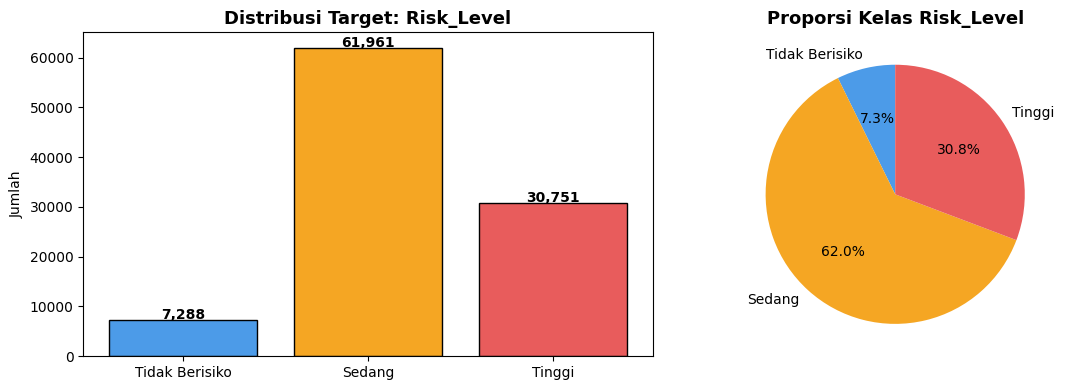

In [8]:
# Distribusi Risk_Level
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_risk['Risk_Level'].value_counts().sort_index()
labels = ['Tidak Berisiko', 'Sedang', 'Tinggi']
colors = ['#4C9BE8', '#F5A623', '#E85C5C']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribusi Target: Risk_Level', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Kelas Risk_Level', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

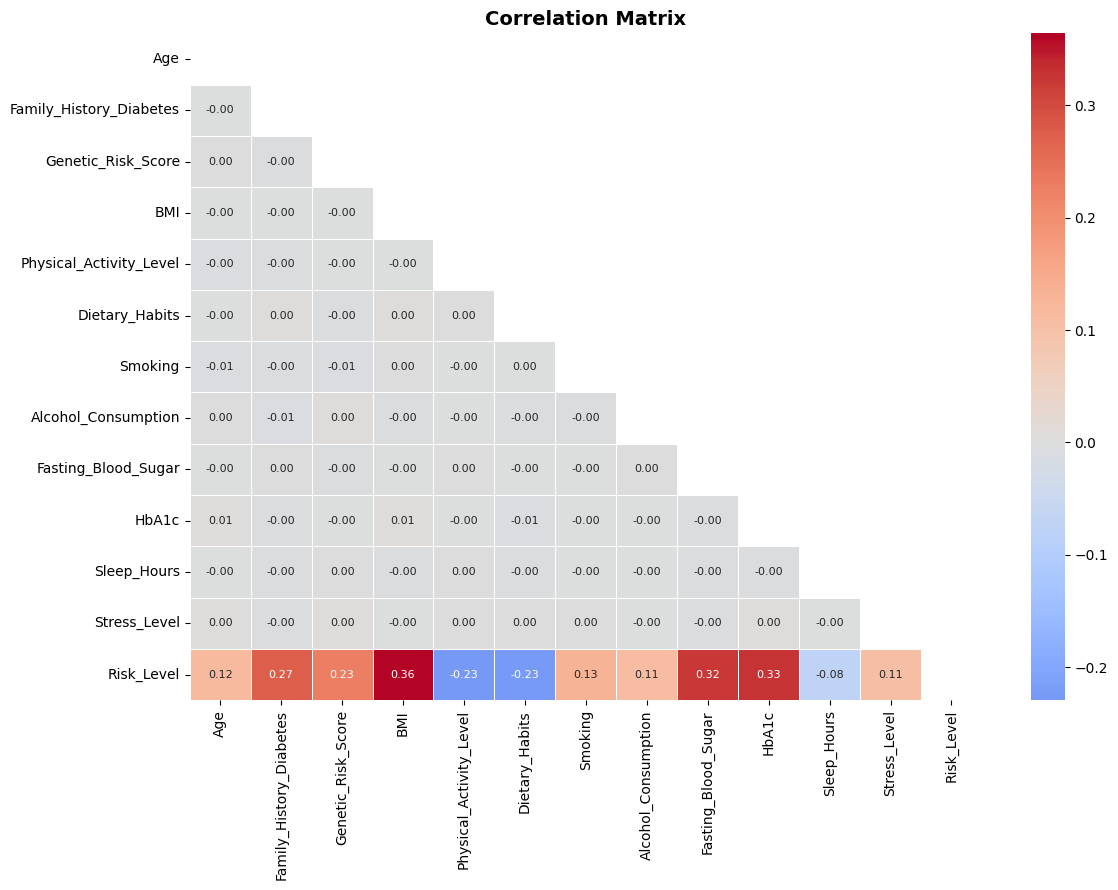

In [9]:
# Correlation heatmap
plt.figure(figsize=(12, 9))
corr = df_risk.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

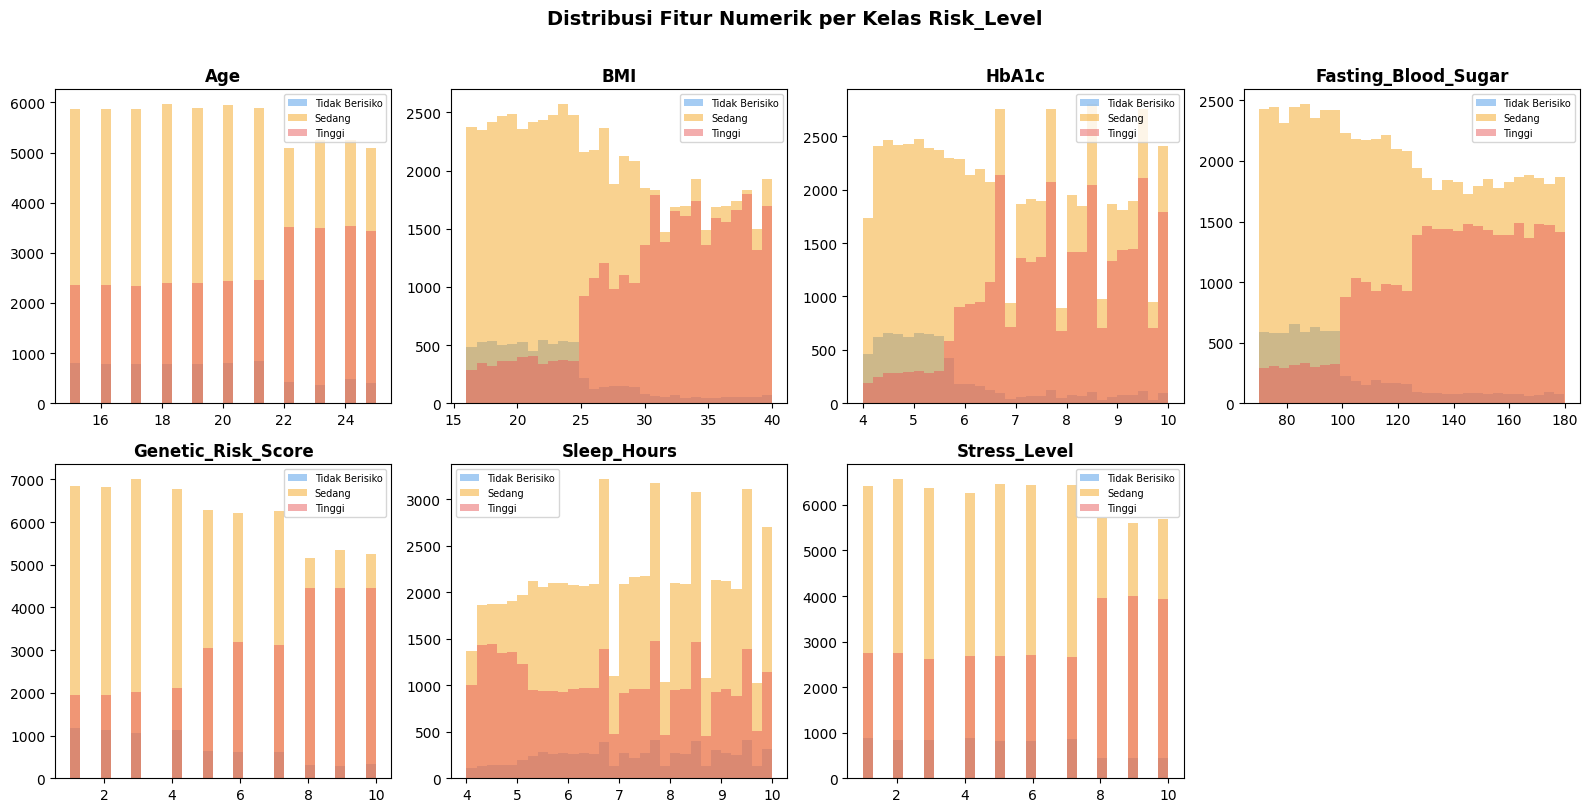

In [10]:
# Distribusi fitur numerik per kelas Risk_Level
num_cols = ['Age', 'BMI', 'HbA1c', 'Fasting_Blood_Sugar',
            'Genetic_Risk_Score', 'Sleep_Hours', 'Stress_Level']

risk_labels = {0: 'Tidak Berisiko', 1: 'Sedang', 2: 'Tinggi'}
colors = ['#4C9BE8', '#F5A623', '#E85C5C']  # biru, oranye, merah

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for cls, color in zip([0, 1, 2], colors):
        subset = df_risk[df_risk['Risk_Level'] == cls][col]
        axes[i].hist(subset, bins=30, alpha=0.5, color=color, label=risk_labels[cls])
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=7)

axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik per Kelas Risk_Level',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## STEP 7 — Split Fitur dan Target

In [11]:
FEATURES = [
    'Age', 'BMI', 'HbA1c', 'Fasting_Blood_Sugar',
    'Genetic_Risk_Score', 'Family_History_Diabetes',
    'Physical_Activity_Level', 'Dietary_Habits',
    'Smoking', 'Alcohol_Consumption',
    'Sleep_Hours', 'Stress_Level'
]
TARGET = 'Risk_Level'

X_risk = df_risk[FEATURES]
y_risk = df_risk[TARGET]

print(f'Shape X (fitur) : {X_risk.shape}')
print(f'Shape y (target): {y_risk.shape}')
print(f'Fitur ({len(FEATURES)}): {FEATURES}')

Shape X (fitur) : (100000, 12)
Shape y (target): (100000,)
Fitur (12): ['Age', 'BMI', 'HbA1c', 'Fasting_Blood_Sugar', 'Genetic_Risk_Score', 'Family_History_Diabetes', 'Physical_Activity_Level', 'Dietary_Habits', 'Smoking', 'Alcohol_Consumption', 'Sleep_Hours', 'Stress_Level']


## STEP 8 — Train-Test Split

In [12]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_risk, y_risk,
    test_size=0.2,
    random_state=42,
    stratify=y_risk        # jaga proporsi kelas di train & test
)

print(f'X_train : {X_train_r.shape}')
print(f'X_test  : {X_test_r.shape}')
print()
print('Distribusi kelas di train:')
print(y_train_r.value_counts(normalize=True).round(3))
print()
print('Distribusi kelas di test:')
print(y_test_r.value_counts(normalize=True).round(3))

X_train : (80000, 12)
X_test  : (20000, 12)

Distribusi kelas di train:
Risk_Level
1    0.620
2    0.308
0    0.073
Name: proportion, dtype: float64

Distribusi kelas di test:
Risk_Level
1    0.620
2    0.308
0    0.073
Name: proportion, dtype: float64


## STEP 9 — Hitung sample_weight (Pengganti SMOTE)

> **Kenapa bukan SMOTE?**
> - Imbalance 70:30 tidak cukup parah untuk butuh data sintetis
> - SMOTE yang diterapkan **sebelum** CV fold menyebabkan **data leakage**
> - `compute_sample_weight` lebih aman, native, dan tidak menambah data
>
> **Cara kerja**: Kelas minoritas diberi bobot lebih tinggi saat training,
> sehingga model tidak bias ke kelas mayoritas.


In [13]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_r)

print('Distribusi bobot per kelas:')
for cls, name in zip([0, 1, 2], ['Tidak Berisiko', 'Sedang', 'Tinggi']):
    mask = y_train_r == cls
    print(f'  {name:<20}: {mask.sum():>6,} sampel | avg weight = {sample_weights[mask].mean():.4f}')

Distribusi bobot per kelas:
  Tidak Berisiko      :  5,830 sampel | avg weight = 4.5740
  Sedang              : 49,569 sampel | avg weight = 0.5380
  Tinggi              : 24,601 sampel | avg weight = 1.0840


## STEP 10 — Training XGBoost

In [14]:
model_risk = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)

model_risk.fit(X_train_r, y_train_r, sample_weight=sample_weights)
print('✅ Model berhasil ditraining!')

✅ Model berhasil ditraining!


## STEP 11 — Cross Validation (5-Fold, Bebas Leakage)

> **Perbaikan dari versi sebelumnya**: `sample_weight` dihitung **di dalam** setiap fold,
> bukan sebelum CV. Ini memastikan data validasi tidak "bocor" ke proses pembobotan.


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_r, y_train_r)):
    X_fold_train = X_train_r.iloc[train_idx]
    y_fold_train = y_train_r.iloc[train_idx]
    X_fold_val   = X_train_r.iloc[val_idx]
    y_fold_val   = y_train_r.iloc[val_idx]

    # Hitung weight HANYA dari data train fold (tidak bocor ke val)
    fold_weights = compute_sample_weight(class_weight='balanced', y=y_fold_train)

    fold_model = clone(model_risk)
    fold_model.fit(X_fold_train, y_fold_train, sample_weight=fold_weights)

    score = fold_model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    print(f'Fold {fold+1}: {score:.4f}')

cv_scores = np.array(cv_scores)
print()
print(f'Mean Accuracy : {cv_scores.mean():.4f}')
print(f'Std           : {cv_scores.std():.4f}')
print(f'Min           : {cv_scores.min():.4f}')
print(f'Max           : {cv_scores.max():.4f}')

Fold 1: 0.9589
Fold 2: 0.9626
Fold 3: 0.9611
Fold 4: 0.9625
Fold 5: 0.9648

Mean Accuracy : 0.9620
Std           : 0.0019
Min           : 0.9589
Max           : 0.9648


## STEP 12 — Evaluasi Model

=== Classification Report ===
                precision    recall  f1-score   support

Tidak Berisiko       0.76      1.00      0.86      1458
        Sedang       0.99      0.95      0.97     12392
        Tinggi       0.97      0.99      0.98      6150

      accuracy                           0.96     20000
     macro avg       0.91      0.98      0.94     20000
  weighted avg       0.97      0.96      0.96     20000



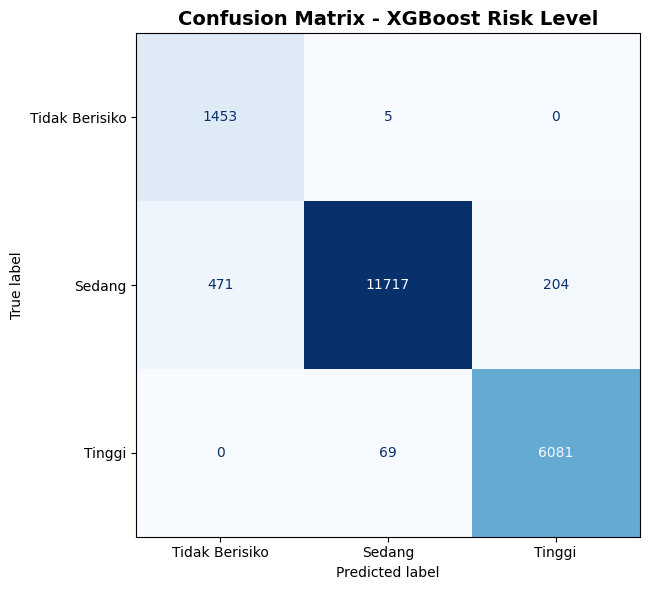

In [16]:
y_pred_r = model_risk.predict(X_test_r)
classes  = ['Tidak Berisiko', 'Sedang', 'Tinggi']

# Classification Report
print('=== Classification Report ===')
print(classification_report(y_test_r, y_pred_r, target_names=classes))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm_r = confusion_matrix(y_test_r, y_pred_r)
ConfusionMatrixDisplay(confusion_matrix=cm_r, display_labels=classes).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('Confusion Matrix - XGBoost Risk Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 13 — FPR & FNR per Kelas

> **Penting dalam konteks medis:**
> - **FNR (False Negative Rate)** = pasien berisiko yang **tidak terdeteksi** → lebih berbahaya
> - **FPR (False Positive Rate)** = pasien normal yang **salah diklasifikasi** berisiko


In [17]:
print('=== FPR dan FNR per Kelas ===')
print(f"{'Kelas':<20} {'TP':>7} {'FP':>7} {'FN':>7} {'TN':>7} {'FPR':>8} {'FNR':>8}")
print('-' * 65)

fprs, fnrs = [], []
for i, kelas in enumerate(classes):
    TP = cm_r[i, i]
    FN = cm_r[i, :].sum() - TP
    FP = cm_r[:, i].sum() - TP
    TN = cm_r.sum() - TP - FP - FN

    FPR = FP / (FP + TN) * 100 if (FP + TN) > 0 else 0
    FNR = FN / (FN + TP) * 100 if (FN + TP) > 0 else 0

    fprs.append(FPR)
    fnrs.append(FNR)

    print(f'{kelas:<20} {TP:>7,} {FP:>7,} {FN:>7,} {TN:>7,} {FPR:>7.2f}% {FNR:>7.2f}%')

print('-' * 65)
print(f"{'Macro Avg':<20} {'':>7} {'':>7} {'':>7} {'':>7} {np.mean(fprs):>7.2f}% {np.mean(fnrs):>7.2f}%")

=== FPR dan FNR per Kelas ===
Kelas                     TP      FP      FN      TN      FPR      FNR
-----------------------------------------------------------------
Tidak Berisiko         1,453     471       5  18,071    2.54%    0.34%
Sedang                11,717      74     675   7,534    0.97%    5.45%
Tinggi                 6,081     204      69  13,646    1.47%    1.12%
-----------------------------------------------------------------
Macro Avg                                               1.66%    2.30%


## STEP 14 — ROC-AUC Multiclass

In [18]:
y_prob_r = model_risk.predict_proba(X_test_r)
roc_auc  = roc_auc_score(y_test_r, y_prob_r, multi_class='ovr', average='weighted')

print(f'ROC-AUC Score (weighted OvR): {roc_auc:.4f}')
print()
print('Interpretasi:')
print('  ≥ 0.90 : Excellent')
print('  ≥ 0.80 : Good')
print('  ≥ 0.70 : Fair')
print(f'  → Model ini: {"Excellent ✅" if roc_auc >= 0.90 else "Good ✅" if roc_auc >= 0.80 else "Fair ⚠️"}')

ROC-AUC Score (weighted OvR): 0.9977

Interpretasi:
  ≥ 0.90 : Excellent
  ≥ 0.80 : Good
  ≥ 0.70 : Fair
  → Model ini: Excellent ✅


## STEP 15 — Feature Importance

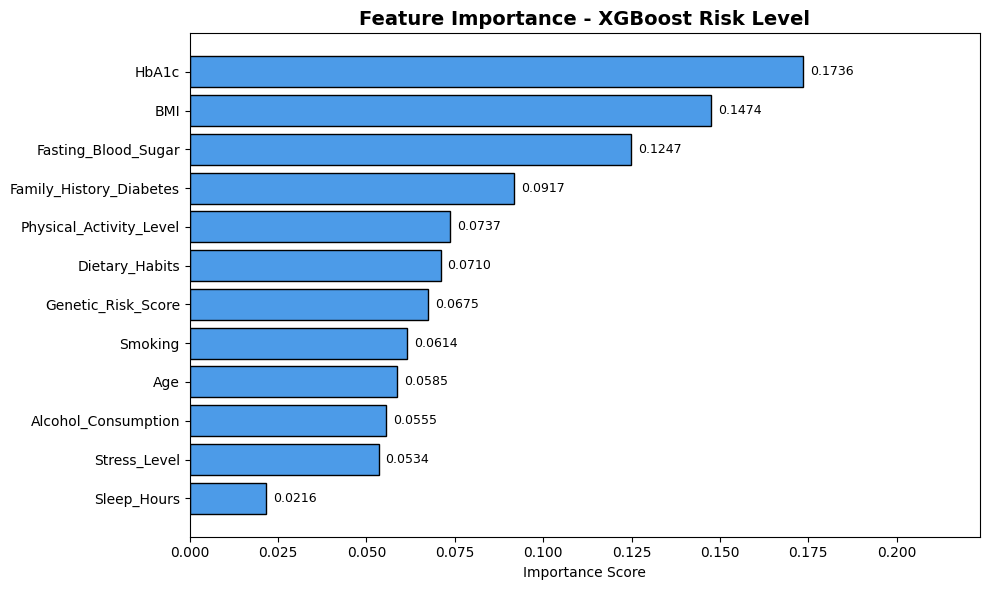


Top 5 Fitur Paling Penting:
  1. HbA1c                          0.1736
  2. BMI                            0.1474
  3. Fasting_Blood_Sugar            0.1247
  4. Family_History_Diabetes        0.0917
  5. Physical_Activity_Level        0.0737


In [19]:
importance    = model_risk.feature_importances_
feature_names = X_risk.columns.tolist()
indices       = np.argsort(importance)[::-1]
sorted_feats  = [feature_names[i] for i in indices]
sorted_imp    = importance[indices]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sorted_feats[::-1], sorted_imp[::-1], color='#4C9BE8', edgecolor='black')

for bar, val in zip(bars, sorted_imp[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title('Feature Importance - XGBoost Risk Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_xlim(0, max(sorted_imp) + 0.05)
plt.tight_layout()
plt.show()

print()
print('Top 5 Fitur Paling Penting:')
for i in range(5):
    print(f'  {i+1}. {sorted_feats[i]:<30} {sorted_imp[i]:.4f}')

---
## ✅ Ringkasan Pipeline

| Item | Nilai |
|---|---|
| Total data | 100,000 baris |
| Fitur final | 12 fitur |
| Target | `Risk_Level` (3 kelas) |
| Training set | 80,000 baris |
| Test set | 20,000 baris |
| Missing value | 0 |
| Imbalance handling | `compute_sample_weight(balanced)` |
| Cross Validation | 5-Fold Stratified (bebas leakage) |
| Evaluasi tambahan | FPR, FNR, ROC-AUC multiclass |


# Step 16 - Save Model


In [20]:
import joblib
import os

model_path = "../models"
os.makedirs(model_path, exist_ok=True)

# Save model
joblib.dump(model_risk, f"{model_path}/model_xgboost_risk_level.pkl")
print('✅ Model berhasil disimpan!')

print("Model dan komponen pendukung berhasil disimpan.")
print(f"File tersimpan di folder {model_path}")

# Load model (kalau mau pakai lagi)
model_loaded = joblib.load('model_xgboost_risk_level.pkl')


✅ Model berhasil disimpan!
Model dan komponen pendukung berhasil disimpan.
File tersimpan di folder ../models


FileNotFoundError: [Errno 2] No such file or directory: 'model_xgboost_risk_level.pkl'